In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

os.chdir('/content/drive/MyDrive/FPL')

print(os.getcwd())
print(os.listdir())

Mounted at /content/drive
/content/drive/MyDrive/FPL
['merged_player_data_1.csv', 'merged_player_data_1.gsheet', 'cleaned_merged_seasons_team_aggregated.csv', 'cleaned_merged_seasons_team_aggregated.gsheet', 'active_perfect_understat_enhanced.csv', 'Untitled0.ipynb']


# Linear Regression

This model uses the current gameweek’s player statistics to predict the player’s points in the next gameweek. It serves as a simple baseline model, assuming a linear relationship between the input features and the target variable.

In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

# =========================
# 1. Load new enhanced data
# =========================
df = pd.read_csv("active_perfect_understat_enhanced.csv")

# =========================
# 2. Drop all xG / xA related columns
# =========================
drop_x_cols = [
    "xg", "xa", "xg_chain", "xg_buildup",
    "form_xg_3", "form_xa_3",
    "form_xg_5", "form_xa_5",
    "form_xg_10", "form_xa_10"
]

drop_x_cols = [c for c in drop_x_cols if c in df.columns]
df = df.drop(columns=drop_x_cols)

# =========================
# 3. Basic time formatting
# =========================
df["kickoff_time"] = pd.to_datetime(df["kickoff_time"], errors="coerce")

# =========================
# 4. Remove duplicated copies of the same match row
# Rule:
# - same season/player/round/game_id may appear more than once
# - keep the row whose "gameweek" is closest to "round"
# - if tied, keep the one with larger gameweek
# =========================
df["gw_distance"] = (df["gameweek"] - df["round"]).abs()
df["gw_distance"] = df["gw_distance"].fillna(999)

df = df.sort_values(
    ["season_x", "element", "round", "game_id", "gw_distance", "gameweek"],
    ascending=[True, True, True, True, True, False]
)

df = df.drop_duplicates(
    subset=["season_x", "element", "round", "game_id"],
    keep="first"
).copy()

# =========================
# 5. Create home/away match counts for each GW
# This is better than using a single binary is_home
# because some gameweeks may contain multiple matches
# =========================
df["is_home"] = df["is_home"].fillna(0)
df["home_matches"] = df["is_home"]
df["away_matches"] = 1 - df["is_home"]

# =========================
# 6. Aggregate current-gameweek match stats
# One row per player per gameweek
# =========================
group_cols = ["season_x", "element", "round"]

agg_stats = {
    "minutes_x": "sum",
    "goals_scored": "sum",
    "assists_x": "sum",
    "clean_sheets": "sum",
    "bonus": "sum",
    "bps": "sum",
    "shots": "sum",
    "key_passes_y": "sum",
    "total_points": "sum",
    "home_matches": "sum",
    "away_matches": "sum",
    "influence": "mean",
    "creativity": "mean",
    "threat": "mean"
}

stats_df = df.groupby(group_cols, as_index=False).agg(agg_stats)

# =========================
# 7. For rolling / season features, keep the latest row
# inside that gameweek (end-of-GW snapshot)
# =========================
snapshot_cols = [
    "player",
    "price",
    "form_pts_3",
    "form_goals_3",
    "form_assists_3",
    "form_minutes_3",
    "form_bps_3",
    "form_shots_3",
    "form_key_passes_y_3",
    "form_influence_3",
    "form_creativity_3",
    "season_goals",
    "season_assists",
    "season_minutes",
    "games_played_season",
    "clean_sheets_season",
    "clean_sheet_form"
]

snapshot_cols = [c for c in snapshot_cols if c in df.columns]

latest_df = (
    df.sort_values(["season_x", "element", "round", "kickoff_time"])
      .groupby(group_cols, as_index=False)
      .tail(1)
)

latest_df = latest_df[group_cols + snapshot_cols]

# =========================
# 8. Merge aggregated stats + latest snapshot features
# =========================
data = stats_df.merge(latest_df, on=group_cols, how="left")

# =========================
# 9. Sort and create target variable
# next_gw_points = total points in the next gameweek
# =========================
data = data.sort_values(["season_x", "element", "round"]).copy()
data["next_gw_points"] = data.groupby(["season_x", "element"])["total_points"].shift(-1)

# =========================
# 10. Select features (NO xG / xA)
# =========================
features = [
    "minutes_x",
    "goals_scored",
    "assists_x",
    "clean_sheets",
    "bonus",
    "bps",
    "shots",
    "key_passes_y",
    "influence",
    "creativity",
    "threat",
    "home_matches",
    "away_matches",
    "price",
    "form_pts_3",
    "form_goals_3",
    "form_assists_3",
    "form_minutes_3",
    "form_bps_3",
    "form_shots_3",
    "form_key_passes_y_3",
    "form_influence_3",
    "form_creativity_3",
    "season_goals",
    "season_assists",
    "season_minutes",
    "games_played_season",
    "clean_sheets_season",
    "clean_sheet_form"
]

features = [c for c in features if c in data.columns]
target = "next_gw_points"

# =========================
# 11. Keep only required columns and drop missing values
# =========================
model_data = data[features + [target]].dropna().copy()

X = model_data[features]
y = model_data[target]

# =========================
# 12. Train-test split
# Same style as your old code for easy comparison
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 13. Train linear regression
# =========================
model = LinearRegression()
model.fit(X_train, y_train)

# =========================
# 14. Predict
# =========================
y_pred = model.predict(X_test)

# =========================
# 15. Evaluate
# =========================
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("Number of features:", len(features))
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

# =========================
# 16. Show coefficients
# =========================
coef_df = pd.DataFrame({
    "feature": features,
    "coefficient": model.coef_
}).sort_values("coefficient", ascending=False)

print("\nFeature coefficients:")
print(coef_df)

# =========================
# 17. Preview predictions
# =========================
results = pd.DataFrame({
    "actual_next_gw_points": y_test.values,
    "predicted_next_gw_points": y_pred
})

print("\nPrediction sample:")
print(results.head(10))

Training samples: 45252
Testing samples: 11314
Number of features: 29
MAE: 2.143
RMSE: 2.952

Feature coefficients:
                feature  coefficient
13                price     0.342034
3          clean_sheets     0.172976
19         form_shots_3     0.083352
1          goals_scored     0.076639
14           form_pts_3     0.057602
27  clean_sheets_season     0.043113
23         season_goals     0.033479
24       season_assists     0.027993
6                 shots     0.018493
21     form_influence_3     0.009396
9            creativity     0.007241
22    form_creativity_3     0.007191
5                   bps     0.007014
0             minutes_x     0.006922
18           form_bps_3     0.006071
17       form_minutes_3     0.002874
2             assists_x     0.002290
8             influence     0.002261
10               threat     0.001507
25       season_minutes    -0.000019
26  games_played_season    -0.002025
4                 bonus    -0.038400
7          key_passes_y    -0.074

# Single XG boost

This model uses the same prediction task but applies XGBoost instead of linear regression. Unlike the baseline model, it is able to capture more complex and non-linear relationships in the data, which may improve predictive performance.

In [3]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. Load new enhanced data
# =========================
df = pd.read_csv("active_perfect_understat_enhanced.csv")

# =========================
# 2. Drop all xG / xA related columns
# =========================
drop_x_cols = [
    "xg", "xa", "xg_chain", "xg_buildup",
    "form_xg_3", "form_xa_3",
    "form_xg_5", "form_xa_5",
    "form_xg_10", "form_xa_10"
]

drop_x_cols = [c for c in drop_x_cols if c in df.columns]
df = df.drop(columns=drop_x_cols)

# =========================
# 3. Basic time formatting
# =========================
df["kickoff_time"] = pd.to_datetime(df["kickoff_time"], errors="coerce")

# =========================
# 4. Remove duplicated copies of the same match row
# Keep the row whose "gameweek" is closest to "round"
# =========================
df["gw_distance"] = (df["gameweek"] - df["round"]).abs()
df["gw_distance"] = df["gw_distance"].fillna(999)

df = df.sort_values(
    ["season_x", "element", "round", "game_id", "gw_distance", "gameweek"],
    ascending=[True, True, True, True, True, False]
)

df = df.drop_duplicates(
    subset=["season_x", "element", "round", "game_id"],
    keep="first"
).copy()

# =========================
# 5. Create home / away match counts
# Useful for double gameweeks
# =========================
df["is_home"] = df["is_home"].fillna(0)
df["home_matches"] = df["is_home"]
df["away_matches"] = 1 - df["is_home"]

# =========================
# 6. Aggregate to one row per player per gameweek
# =========================
group_cols = ["season_x", "element", "round"]

agg_stats = {
    "minutes_x": "sum",
    "goals_scored": "sum",
    "assists_x": "sum",
    "clean_sheets": "sum",
    "bonus": "sum",
    "bps": "sum",
    "shots": "sum",
    "key_passes_y": "sum",
    "total_points": "sum",
    "home_matches": "sum",
    "away_matches": "sum",
    "influence": "mean",
    "creativity": "mean",
    "threat": "mean"
}

stats_df = df.groupby(group_cols, as_index=False).agg(agg_stats)

# =========================
# 7. Keep latest snapshot features within the same GW
# =========================
snapshot_cols = [
    "player",
    "price",
    "FPL_pos",
    "form_pts_3",
    "form_goals_3",
    "form_assists_3",
    "form_minutes_3",
    "form_bps_3",
    "form_shots_3",
    "form_key_passes_y_3",
    "form_influence_3",
    "form_creativity_3",
    "season_goals",
    "season_assists",
    "season_minutes",
    "games_played_season",
    "clean_sheets_season",
    "clean_sheet_form"
]

snapshot_cols = [c for c in snapshot_cols if c in df.columns]

latest_df = (
    df.sort_values(["season_x", "element", "round", "kickoff_time"])
      .groupby(group_cols, as_index=False)
      .tail(1)
)

latest_df = latest_df[group_cols + snapshot_cols]

# =========================
# 8. Merge aggregated stats + latest snapshot features
# =========================
data = stats_df.merge(latest_df, on=group_cols, how="left")

# =========================
# 9. Sort and create target
# next_gw_points = total points in the next gameweek
# =========================
data = data.sort_values(["season_x", "round", "element"]).copy()
data["next_gw_points"] = data.groupby(["season_x", "element"])["total_points"].shift(-1)

# =========================
# 10. Select features (NO xG / xA)
# =========================
features = [
    "minutes_x",
    "goals_scored",
    "assists_x",
    "clean_sheets",
    "bonus",
    "bps",
    "shots",
    "key_passes_y",
    "influence",
    "creativity",
    "threat",
    "home_matches",
    "away_matches",
    "price",
    "FPL_pos",
    "form_pts_3",
    "form_goals_3",
    "form_assists_3",
    "form_minutes_3",
    "form_bps_3",
    "form_shots_3",
    "form_key_passes_y_3",
    "form_influence_3",
    "form_creativity_3",
    "season_goals",
    "season_assists",
    "season_minutes",
    "games_played_season",
    "clean_sheets_season",
    "clean_sheet_form"
]

features = [c for c in features if c in data.columns]
target = "next_gw_points"

# =========================
# 11. Prepare model data
# For XGBoost, keep missing feature values
# Only drop rows with missing target
# =========================
model_data = data[features + [target]].copy()
model_data = model_data.dropna(subset=[target])

# One-hot encode player position
if "FPL_pos" in model_data.columns:
    model_data = pd.get_dummies(model_data, columns=["FPL_pos"], drop_first=False)

X = model_data.drop(columns=[target])
y = model_data[target]

# =========================
# 12. Chronological split
# 70% train / 15% valid / 15% test
# =========================
n = len(model_data)
train_end = int(n * 0.70)
valid_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_valid = X.iloc[train_end:valid_end]
y_valid = y.iloc[train_end:valid_end]

X_test = X.iloc[valid_end:]
y_test = y.iloc[valid_end:]

# =========================
# 13. Train improved XGBoost
# =========================
model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=4,
    min_child_weight=10,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    tree_method="hist",
    random_state=42,
    eval_metric="rmse",
    early_stopping_rounds=50
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# =========================
# 14. Predict
# =========================
y_pred = model.predict(X_test)

# =========================
# 15. Evaluate
# =========================
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print("Training samples:", len(X_train))
print("Validation samples:", len(X_valid))
print("Testing samples:", len(X_test))
print("Number of features:", X.shape[1])
print("Best iteration:", model.best_iteration)
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))

# =========================
# 16. Feature importance
# =========================
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nFeature importances:")
print(importance_df.head(20))

# =========================
# 17. Prediction sample
# =========================
results = pd.DataFrame({
    "actual_next_gw_points": y_test.values,
    "predicted_next_gw_points": y_pred
})

print("\nPrediction sample:")
print(results.head(10))

Training samples: 41785
Validation samples: 8954
Testing samples: 8955
Number of features: 33
Best iteration: 206
MAE: 2.07
RMSE: 2.894

Feature importances:
                feature  importance
0             minutes_x    0.110290
13                price    0.105364
31           FPL_pos_GK    0.053179
17       form_minutes_3    0.052476
23         season_goals    0.051810
27  clean_sheets_season    0.047807
8             influence    0.028176
14           form_pts_3    0.027713
22    form_creativity_3    0.026536
5                   bps    0.025936
1          goals_scored    0.025502
19         form_shots_3    0.025379
3          clean_sheets    0.024106
18           form_bps_3    0.024045
25       season_minutes    0.023809
10               threat    0.023373
11         home_matches    0.022962
9            creativity    0.022720
24       season_assists    0.022689
21     form_influence_3    0.021539

Prediction sample:
   actual_next_gw_points  predicted_next_gw_points
0              

# Position Regression

This model separates players by FPL position and trains a different XGBoost model for each group, such as goalkeepers, defenders, midfielders, and forwards. The idea is to better reflect the different scoring patterns of each position when predicting next-gameweek points.

In [4]:
import pandas as pd
import numpy as np

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================
# 1. Load data
# =========================
df = pd.read_csv("active_perfect_understat_enhanced.csv")

# =========================
# 2. Drop all xG / xA related columns
# =========================
drop_x_cols = [
    "xg", "xa", "xg_chain", "xg_buildup",
    "form_xg_3", "form_xa_3",
    "form_xg_5", "form_xa_5",
    "form_xg_10", "form_xa_10"
]

drop_x_cols = [c for c in drop_x_cols if c in df.columns]
df = df.drop(columns=drop_x_cols)

# =========================
# 3. Basic time formatting
# =========================
df["kickoff_time"] = pd.to_datetime(df["kickoff_time"], errors="coerce")

# =========================
# 4. Fill missing FPL positions
# We use the raw 'position' column to infer FPL_pos
# and drop 'Sub'
# =========================
def map_position_to_fpl(raw_pos):
    if pd.isna(raw_pos):
        return np.nan

    # Goalkeeper
    if raw_pos == "GK":
        return "GK"

    # Defender
    if raw_pos in ["DC", "DL", "DR"]:
        return "DEF"

    # Midfielder
    if raw_pos in [
        "MC", "ML", "MR",
        "AMC", "AML", "AMR",
        "DMC", "DML", "DMR",
        "FWL", "FWR"
    ]:
        return "MID"

    # Forward
    if raw_pos == "FW":
        return "FWD"

    # Bench / unknown
    if raw_pos == "Sub":
        return np.nan

    return np.nan

df["FPL_pos_filled"] = df["FPL_pos"]
missing_mask = df["FPL_pos_filled"].isna()
df.loc[missing_mask, "FPL_pos_filled"] = df.loc[missing_mask, "position"].apply(map_position_to_fpl)

# Drop rows still without usable FPL position
df = df.dropna(subset=["FPL_pos_filled"]).copy()

# =========================
# 5. Remove duplicated copies of the same match row
# Keep the row whose gameweek is closest to round
# =========================
df["gw_distance"] = (df["gameweek"] - df["round"]).abs()
df["gw_distance"] = df["gw_distance"].fillna(999)

df = df.sort_values(
    ["season_x", "element", "round", "game_id", "gw_distance", "gameweek"],
    ascending=[True, True, True, True, True, False]
)

df = df.drop_duplicates(
    subset=["season_x", "element", "round", "game_id"],
    keep="first"
).copy()

# =========================
# 6. Create home / away match counts
# Useful for double gameweeks
# =========================
df["is_home"] = df["is_home"].fillna(0)
df["home_matches"] = df["is_home"]
df["away_matches"] = 1 - df["is_home"]

# =========================
# 7. Aggregate match stats to player-gameweek level
# =========================
group_cols = ["season_x", "element", "round"]

agg_stats = {
    "minutes_x": "sum",
    "goals_scored": "sum",
    "assists_x": "sum",
    "clean_sheets": "sum",
    "bonus": "sum",
    "bps": "sum",
    "shots": "sum",
    "key_passes_y": "sum",
    "total_points": "sum",
    "home_matches": "sum",
    "away_matches": "sum",
    "influence": "mean",
    "creativity": "mean",
    "threat": "mean"
}

stats_df = df.groupby(group_cols, as_index=False).agg(agg_stats)

# =========================
# 8. Keep latest snapshot features within each GW
# =========================
snapshot_cols = [
    "player",
    "price",
    "FPL_pos_filled",
    "form_pts_3",
    "form_goals_3",
    "form_assists_3",
    "form_minutes_3",
    "form_bps_3",
    "form_shots_3",
    "form_key_passes_y_3",
    "form_influence_3",
    "form_creativity_3",
    "season_goals",
    "season_assists",
    "season_minutes",
    "games_played_season",
    "clean_sheets_season",
    "clean_sheet_form"
]

snapshot_cols = [c for c in snapshot_cols if c in df.columns]

latest_df = (
    df.sort_values(["season_x", "element", "round", "kickoff_time"])
      .groupby(group_cols, as_index=False)
      .tail(1)
)

latest_df = latest_df[group_cols + snapshot_cols]

# =========================
# 9. Merge aggregated stats + latest snapshot features
# =========================
data = stats_df.merge(latest_df, on=group_cols, how="left")

# =========================
# 10. Sort and create target
# next_gw_points = total points in next gameweek
# =========================
data = data.sort_values(["season_x", "round", "element"]).copy()
data["next_gw_points"] = data.groupby(["season_x", "element"])["total_points"].shift(-1)

# =========================
# 11. Select features (NO xG / xA)
# =========================
features = [
    "minutes_x",
    "goals_scored",
    "assists_x",
    "clean_sheets",
    "bonus",
    "bps",
    "shots",
    "key_passes_y",
    "influence",
    "creativity",
    "threat",
    "home_matches",
    "away_matches",
    "price",
    "form_pts_3",
    "form_goals_3",
    "form_assists_3",
    "form_minutes_3",
    "form_bps_3",
    "form_shots_3",
    "form_key_passes_y_3",
    "form_influence_3",
    "form_creativity_3",
    "season_goals",
    "season_assists",
    "season_minutes",
    "games_played_season",
    "clean_sheets_season",
    "clean_sheet_form"
]

features = [c for c in features if c in data.columns]
target = "next_gw_points"

# Only drop rows with missing target
model_data = data[["season_x", "round", "element", "player", "FPL_pos_filled"] + features + [target]].copy()
model_data = model_data.dropna(subset=[target])

# =========================
# 12. Train one XGBoost model per position
# =========================
positions = ["GK", "DEF", "MID", "FWD"]

all_predictions = []
position_summaries = []
importance_tables = {}

for pos in positions:
    pos_df = model_data[model_data["FPL_pos_filled"] == pos].copy()
    pos_df = pos_df.sort_values(["season_x", "round", "element"]).reset_index(drop=True)

    if len(pos_df) < 500:
        print(f"\nSkipping {pos}: not enough samples ({len(pos_df)})")
        continue

    X = pos_df[features]
    y = pos_df[target]

    # Chronological split inside this position
    n = len(pos_df)
    train_end = int(n * 0.70)
    valid_end = int(n * 0.85)

    X_train = X.iloc[:train_end]
    y_train = y.iloc[:train_end]

    X_valid = X.iloc[train_end:valid_end]
    y_valid = y.iloc[train_end:valid_end]

    X_test = X.iloc[valid_end:]
    y_test = y.iloc[valid_end:]

    meta_test = pos_df.iloc[valid_end:][["season_x", "round", "element", "player", "FPL_pos_filled"]].copy()

    model = XGBRegressor(
        objective="reg:squarederror",
        n_estimators=1000,
        learning_rate=0.03,
        max_depth=4,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.1,
        reg_lambda=1.0,
        tree_method="hist",
        random_state=42,
        eval_metric="rmse",
        early_stopping_rounds=50
    )

    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        verbose=False
    )

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5

    print(f"\n===== {pos} =====")
    print("Training samples:", len(X_train))
    print("Validation samples:", len(X_valid))
    print("Testing samples:", len(X_test))
    print("Best iteration:", model.best_iteration)
    print("MAE:", round(mae, 3))
    print("RMSE:", round(rmse, 3))

    # Save summary
    position_summaries.append({
        "position": pos,
        "train_samples": len(X_train),
        "valid_samples": len(X_valid),
        "test_samples": len(X_test),
        "best_iteration": model.best_iteration,
        "MAE": mae,
        "RMSE": rmse
    })

    # Save feature importance
    importance_df = pd.DataFrame({
        "feature": features,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    importance_tables[pos] = importance_df

    print("\nTop 10 feature importances:")
    print(importance_df.head(10))

    # Save test predictions
    pred_df = meta_test.copy()
    pred_df["actual_next_gw_points"] = y_test.values
    pred_df["predicted_next_gw_points"] = y_pred
    all_predictions.append(pred_df)

# =========================
# 13. Combine all position predictions
# =========================
if len(all_predictions) > 0:
    final_preds = pd.concat(all_predictions, ignore_index=True)

    overall_mae = mean_absolute_error(
        final_preds["actual_next_gw_points"],
        final_preds["predicted_next_gw_points"]
    )
    overall_rmse = mean_squared_error(
        final_preds["actual_next_gw_points"],
        final_preds["predicted_next_gw_points"]
    ) ** 0.5

    summary_df = pd.DataFrame(position_summaries)

    print("\n==============================")
    print("POSITION-SPECIFIC XGBOOST SUMMARY")
    print("==============================")
    print(summary_df)

    print("\nOverall MAE:", round(overall_mae, 3))
    print("Overall RMSE:", round(overall_rmse, 3))

    print("\nPrediction sample:")
    print(final_preds.head(10))
else:
    print("No position-specific predictions were generated.")


===== GK =====
Training samples: 2616
Validation samples: 561
Testing samples: 561
Best iteration: 2
MAE: 2.272
RMSE: 2.74

Top 10 feature importances:
                feature  importance
14           form_pts_3    0.068578
26  games_played_season    0.065032
22    form_creativity_3    0.064970
3          clean_sheets    0.058570
21     form_influence_3    0.057520
13                price    0.055335
25       season_minutes    0.053534
12         away_matches    0.053030
28     clean_sheet_form    0.052414
18           form_bps_3    0.050824

===== DEF =====
Training samples: 11756
Validation samples: 2519
Testing samples: 2520
Best iteration: 59
MAE: 2.422
RMSE: 3.093

Top 10 feature importances:
                feature  importance
13                price    0.091912
4                 bonus    0.046509
27  clean_sheets_season    0.045116
1          goals_scored    0.040488
9            creativity    0.040422
16       form_assists_3    0.039934
3          clean_sheets    0.037537
24  

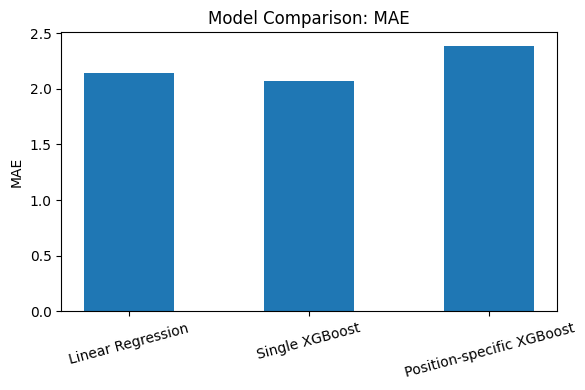

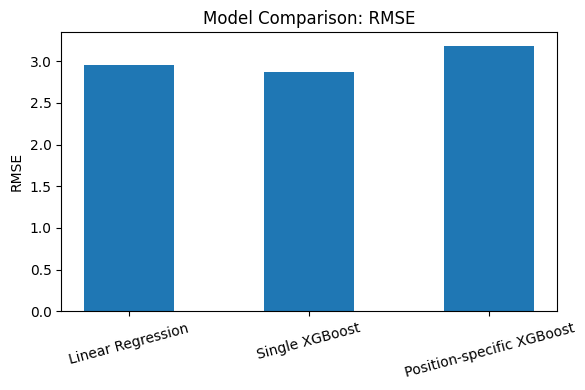

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Overall model comparison
# =========================
overall_results = pd.DataFrame({
    "Model": ["Linear Regression", "Single XGBoost", "Position-specific XGBoost"],
    "MAE": [2.143, 2.069, 2.388],
    "RMSE": [2.952, 2.873, 3.186]
})

# MAE comparison
plt.figure(figsize=(6, 4))
plt.bar(overall_results["Model"], overall_results["MAE"], width=0.5)
plt.title("Model Comparison: MAE")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# RMSE comparison
plt.figure(figsize=(6, 4))
plt.bar(overall_results["Model"], overall_results["RMSE"], width=0.5)
plt.title("Model Comparison: RMSE")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()